In [20]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

from tree_search import *
from tree_analysis import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
data_folder = "../../monkey_4iar/analysis/data/processed/harry/models/2023-02-20"
fold_idx = 0
index = 0

train_data = pd.read_csv(f"{data_folder}/split_{fold_idx}.csv")
trial = train_data.iloc[index]

In [22]:
black_, white_, move_= trial.black, trial.white, trial.move
board = fourbynine_board(fourbynine_pattern(int(black_)), fourbynine_pattern(int(white_)))
actual_move = int(move_).bit_length() - 1

           Parameter :       lo      plo       x0      phi       hi
   pruning_threshold :    0.100    1.000    3.000    6.000   10.000
       stopping_prob :    0.010    0.010    0.300    0.900    1.000
        feature_drop :    0.000    0.000    0.300    0.500    1.000
          lapse_rate :    0.050    0.050    0.100    0.500    1.000
           opp_scale :    0.250    0.500    1.200    2.000    4.000
       center_weight :  -10.000   -5.000    0.400    5.000   10.000
                1IAR :  -10.000   -5.000   -0.500   15.000   20.000
            2IAR_CON :  -10.000   -5.000    2.000   15.000   20.000
            2IAR_DIS :  -10.000   -5.000   -0.900   15.000   20.000
            3IAR_CON :  -10.000   -5.000    6.000   15.000   20.000
            3IAR_DIS :  -10.000   -5.000    4.000   15.000   20.000
                4IAR :  -10.000   -5.000   15.000   15.000   20.000


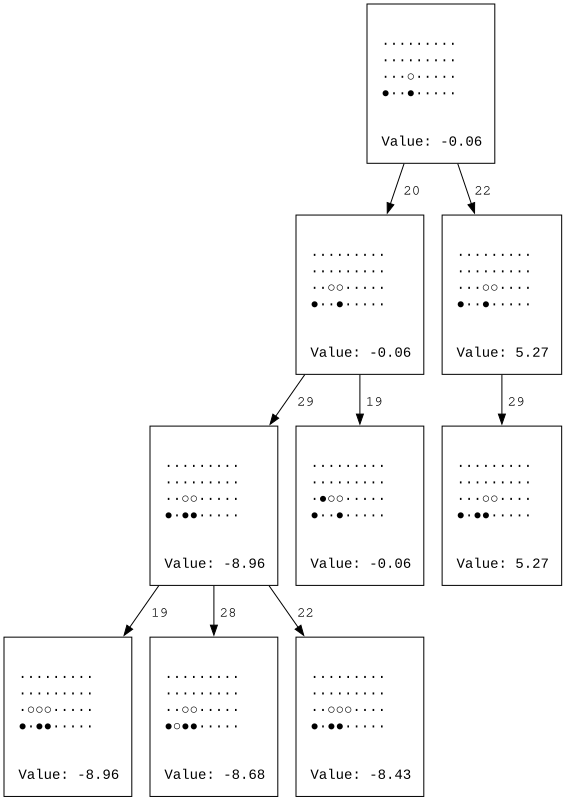

In [58]:
self = TreeSearch()
self.set_params(self.initial_params)
heuristic = self.heuristic
search = fourbynine.NInARowBestFirstSearch(heuristic, board)
search.complete_search()
root = search.get_tree()
tree_to_graphviz(root)

In [ ]:
node = root

hist = np.zeros(36)
for _ in range (100): 
    search = fourbynine.NInARowBestFirstSearch(heuristic, board)
    search.complete_search()
    root = search.get_tree()
    pv = get_principal_variation(root)
    hist[np.array(pv)] += 1 # note that this only works if all moves in pv are unique, which must be true in 4IAR



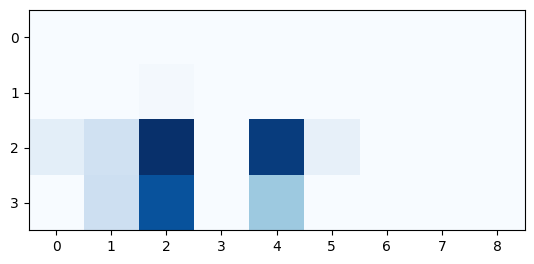

In [92]:
import matplotlib.pyplot as plt
plt.imshow(hist.reshape(4, 9), cmap = "Blues")

In [61]:
hist = get_visits(root, use_paths = True)
plt.imshow(hist.reshape(4, 9))


NameError: name 'get_visits' is not defined

In [25]:
hist = np.zeros(36)
for _ in range (500): 
    search = fourbynine.NInARowBestFirstSearch(heuristic, board)
    search.complete_search()
    root = search.get_tree()
    hist += get_visits(root, use_paths = True)

NameError: name 'get_visits' is not defined

In [26]:
plt.imshow(hist.reshape(4, 9))


NameError: name 'plt' is not defined

[]

[]

[]

In [14]:
pv

[20]